In [1]:
pip install -q torchrs segmentation-models-pytorch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:00


In [2]:
!pip install -q planetary-computer pystac-client rasterio stackstac numpy matplotlib scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 9.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net loaded on cpu
Image: S1A_IW_GRDH_1SDV_20251206T004107_20251206T004132_062187_07C8B6 – 2025-12-06
SAR crop loaded: (2048, 2048, 2)
DEM loaded successfully
Original predicted area: 100.10 km²
After JRC PVE: 3.82 km²
Final area after elevation filter: 1.83 km²

══════════════════════════════════════════════════
 1.83 km²
══════════════════════════════════════════════════


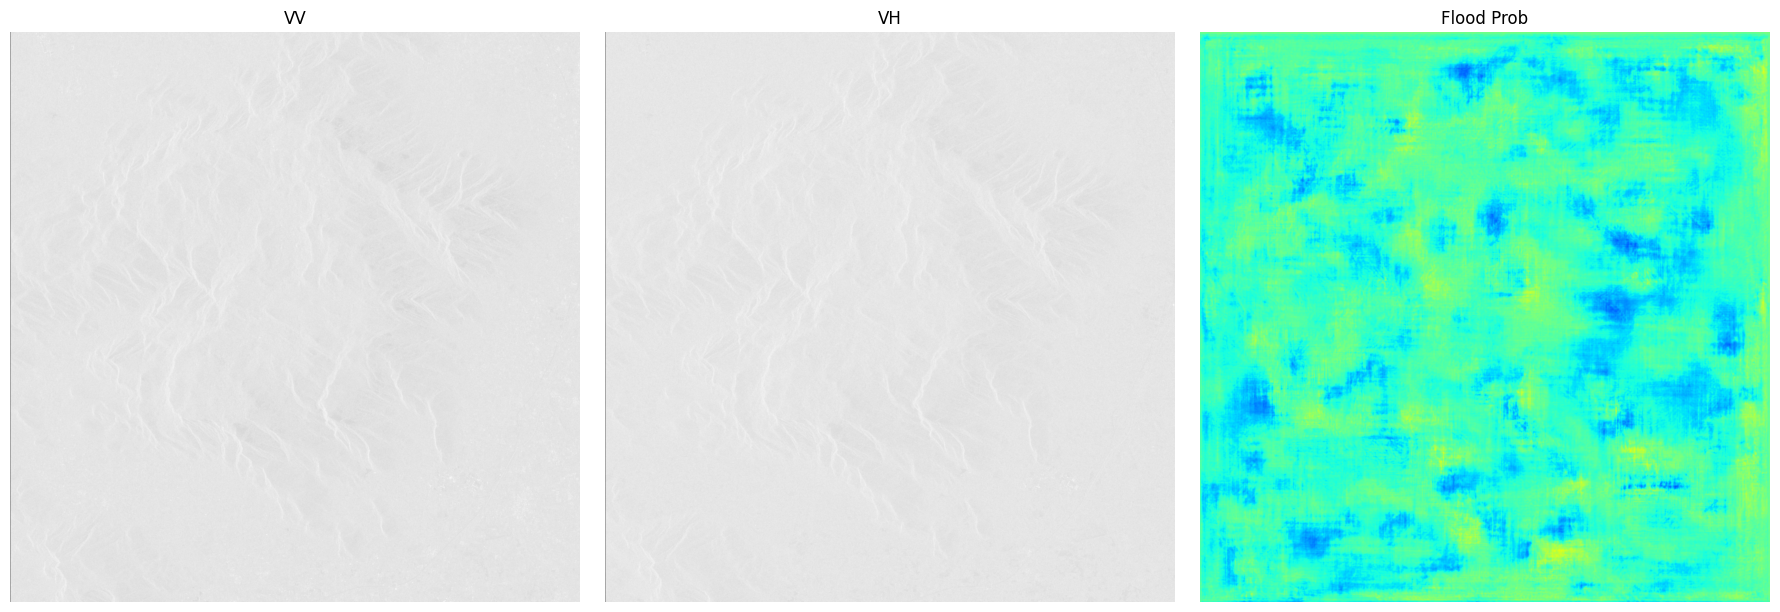

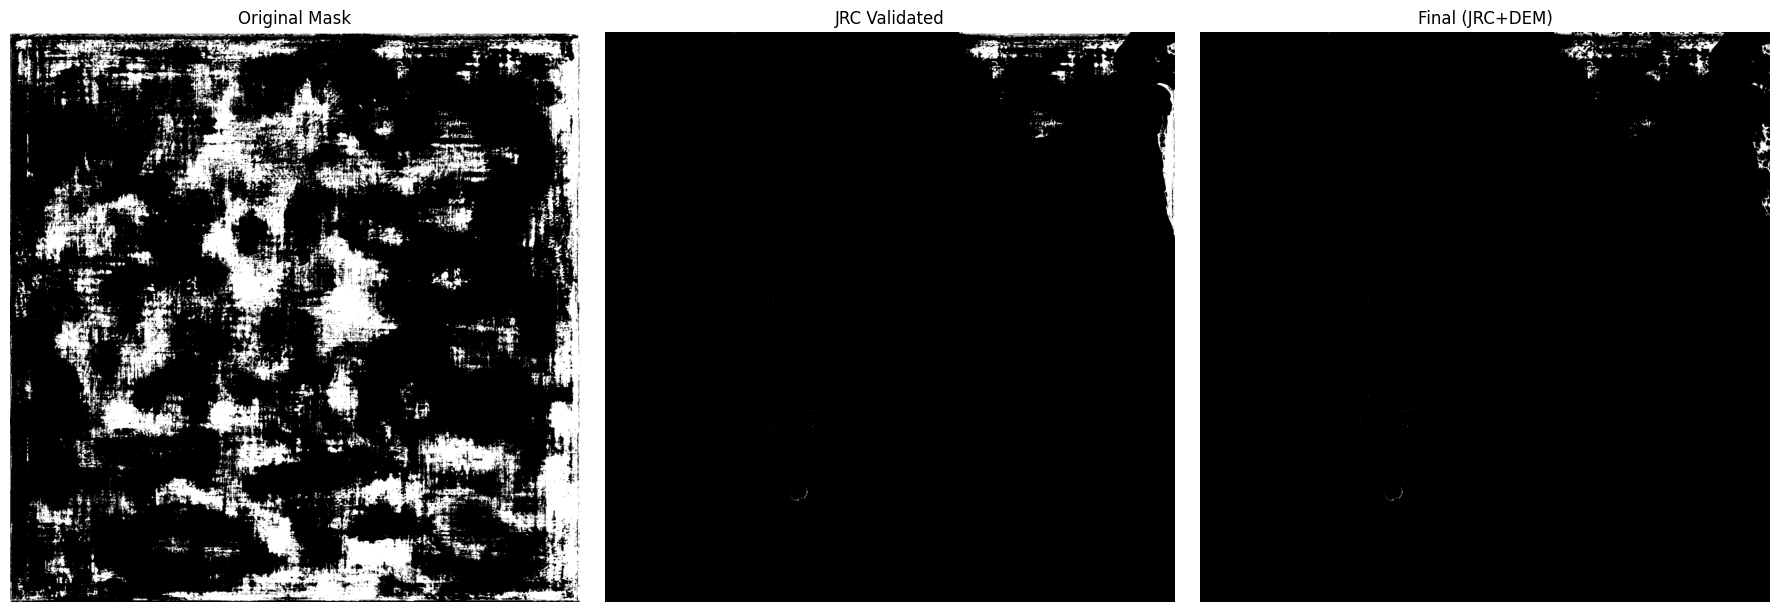

In [3]:
# ────────────────────────────────────────────────────────────────
# ALL-IN-ONE Flood Detection Prototype Cell (with DEM error handling)
# TorchRS-style U-Net + JRC PVE + Elevation Filter + Alert
# Handles missing DEM areas gracefully
# ────────────────────────────────────────────────────────────────

import planetary_computer as pc
from pystac_client import Client
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import torch
from segmentation_models_pytorch import Unet
from scipy.ndimage import zoom

# ────────────────────────────────────────────────
# CONFIG
# ────────────────────────────────────────────────
#BBOX = [76.0, 8.5, 77.5, 10.5]
BBOX = [76.30, 9.35, 76.50, 9.55]   # Kuttanad core flood zone (~20×20 km)
CROP_SIZE = 2048
PROB_THRESHOLD = 0.45
MIN_ALERT_KM2 = 30.0

TELEGRAM_ENABLED = True
BOT_TOKEN = "8661746022:AAG37Xiptb5q0ElglE7i0EItzPz7XN4wPeE"      # e.g. 123456:ABC-DEF1234...
CHAT_ID = "1327577985"
# ────────────────────────────────────────────────
# Choose date (uncomment one)
# ────────────────────────────────────────────────
TIME_RANGE = "2025-12-01/2026-03-01"          # Recent – normal
#TIME_RANGE = "2018-08-01/2018-08-31"        # 2018 flood demo

# ────────────────────────────────────────────────
# Load U-Net
# ────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=2,
    classes=1,
    activation="sigmoid"
).to(device)

model.eval()
print("U-Net loaded on", device)

# ────────────────────────────────────────────────
# Fetch Sentinel-1 SAR
# ────────────────────────────────────────────────
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

search = catalog.search(collections=["sentinel-1-grd"], bbox=BBOX, datetime=TIME_RANGE)
items = list(search.items())

if not items:
    print("No Sentinel-1 image found.")
else:
    item = items[-1]
    print(f"Image: {item.id} – {item.datetime.date()}")

    signed = pc.sign(item)
    vv_url = signed.assets["vv"].href
    vh_url = signed.assets["vh"].href

    window = rasterio.windows.Window(0, 0, CROP_SIZE, CROP_SIZE)

    with rasterio.open(vv_url) as src:
        vv_crop = src.read(1, window=window).astype(np.float32)

    with rasterio.open(vh_url) as src:
        vh_crop = src.read(1, window=window).astype(np.float32)

    sar_crop = np.stack([vv_crop, vh_crop], axis=-1)
    print("SAR crop loaded:", sar_crop.shape)

# ────────────────────────────────────────────────
# Normalize & Predict
# ────────────────────────────────────────────────
vv_norm = (vv_crop - vv_crop.min()) / (vv_crop.max() - vv_crop.min() + 1e-10)
vh_norm = (vh_crop - vh_crop.min()) / (vh_crop.max() - vh_crop.min() + 1e-10)
sar_norm = np.stack([vv_norm, vh_norm], axis=-1)

sar_tensor = torch.from_numpy(sar_norm.transpose(2, 0, 1)).unsqueeze(0).float().to(device)

with torch.no_grad():
    pred_tensor = model(sar_tensor)

pred_prob = pred_tensor.squeeze().cpu().numpy()

# ────────────────────────────────────────────────
# Binary mask
# ────────────────────────────────────────────────
binary_flood = (pred_prob > PROB_THRESHOLD).astype(np.uint8) * 255

# ────────────────────────────────────────────────
# JRC PVE
# ────────────────────────────────────────────────
search_jrc = catalog.search(collections=["jrc-gsw"], bbox=BBOX)
jrc_item = list(search_jrc.items())[0]
signed_jrc = pc.sign(jrc_item)

with rasterio.open(signed_jrc.assets["occurrence"].href) as src:
    occurrence = src.read(1).astype(np.float32)

permanent_water = (occurrence > 90).astype(np.uint8) * 255

jrc_resized = zoom(permanent_water,
                   (pred_prob.shape[0] / permanent_water.shape[0],
                    pred_prob.shape[1] / permanent_water.shape[1]),
                   order=0)

validated_mask = np.logical_and(binary_flood == 255, jrc_resized == 0)

# ────────────────────────────────────────────────
# Elevation Filter (with error handling for missing DEM)
# ────────────────────────────────────────────────
elevation = None
final_mask = validated_mask.copy()  # fallback if DEM fails

try:
    search_dem = catalog.search(collections=["cop-dem-glo-30"], bbox=BBOX)
    if list(search_dem.items()):
        dem_item = list(search_dem.items())[0]
        signed_dem = pc.sign(dem_item)
        dem_url = signed_dem.assets["data"].href

        with rasterio.open(dem_url) as src:
            elevation = src.read(1, window=window).astype(np.float32)

        print("DEM loaded successfully")

        # Filter: keep only low elevation (< 30 m)
        low_elev = elevation < 30
        low_elev = np.nan_to_num(low_elev, nan=True)  # treat NoData as True (conservative)
        final_mask = np.logical_and(validated_mask, low_elev)

    else:
        print("No DEM coverage for this area – skipping elevation filter")
except Exception as e:
    print("DEM fetch failed:", str(e))
    print("Skipping elevation filter – using JRC-validated mask")

# ────────────────────────────────────────────────
# Area calculation + Decision + Alert
# ────────────────────────────────────────────────
original_km2 = np.sum(binary_flood == 255) * 100 / 1_000_000
validated_km2 = np.sum(validated_mask) * 100 / 1_000_000
final_km2 = np.sum(final_mask) * 100 / 1_000_000

print(f"Original predicted area: {original_km2:.2f} km²")
print(f"After JRC PVE: {validated_km2:.2f} km²")
print(f"Final area after elevation filter: {final_km2:.2f} km²")

if final_km2 > MIN_ALERT_KM2:
    status = "CONFIRMED FLOOD"
    alert_msg = f"🚨 FLOOD ALERT!\nArea: {final_km2:.2f} km²\nDate: {item.datetime.date()}\nStatus: {status}"
    print("\n" + "═" * 50)
    print(alert_msg)
    print("═" * 50)
else:
    status = "NORMAL"
    alert_msg = f" {final_km2:.2f} km²"
    print("\n" + "═" * 50)
    print(alert_msg)
    print("═" * 50)

# Telegram (optional)
if TELEGRAM_ENABLED and final_km2 > MIN_ALERT_KM2:
    import requests
    requests.post(f"https://api.telegram.org/bot{BOT_TOKEN}/sendMessage",
                  data={"chat_id": CHAT_ID, "text": alert_msg})

# ────────────────────────────────────────────────
# Visualization
# ────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(10 * np.log10(vv_crop + 1e-10), cmap='gray'); axs[0].set_title('VV'); axs[0].axis('off')
axs[1].imshow(10 * np.log10(vh_crop + 1e-10), cmap='gray'); axs[1].set_title('VH'); axs[1].axis('off')
axs[2].imshow(pred_prob, cmap='jet', vmin=0, vmax=1); axs[2].set_title('Flood Prob'); axs[2].axis('off')
plt.tight_layout()
plt.show()

fig2, axs2 = plt.subplots(1, 3, figsize=(18, 6))
axs2[0].imshow(binary_flood, cmap='gray'); axs2[0].set_title('Original Mask'); axs2[0].axis('off')
axs2[1].imshow(validated_mask.astype(np.uint8)*255, cmap='gray'); axs2[1].set_title('JRC Validated'); axs2[1].axis('off')
axs2[2].imshow(final_mask.astype(np.uint8)*255, cmap='gray'); axs2[2].set_title('Final (JRC+DEM)'); axs2[2].axis('off')
plt.tight_layout()
plt.show()

Dry baseline image: S1A_IW_GRDH_1SDV_20250104T004115_20250104T004140_057287 – 2025-01-04
Change-based flood area (vs dry): 5.26 km²
No significant change – normal conditions.


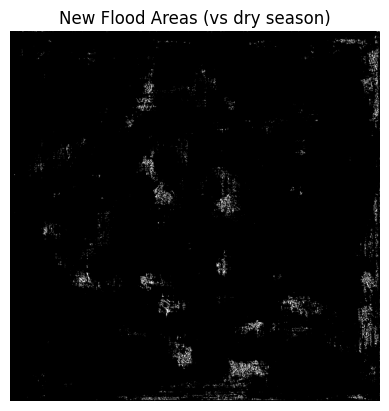

In [4]:
# ────────────────────────────────────────────────
# Change detection: compare with dry season (Jan-Feb)
# + Telegram alert if confirmed flood
# ────────────────────────────────────────────────

DRY_RANGE = "2025-01-01/2025-03-31"  # or "2018-01-01/2018-03-31" for 2018 demo

search_dry = catalog.search(collections=["sentinel-1-grd"], bbox=BBOX, datetime=DRY_RANGE)
dry_items = list(search_dry.items())

if not dry_items:
    print("No dry season baseline image found. Skipping change detection.")
else:
    dry_item = dry_items[-1]
    print(f"Dry baseline image: {dry_item.id} – {dry_item.datetime.date()}")

    signed_dry = pc.sign(dry_item)

    with rasterio.open(signed_dry.assets["vv"].href) as src:
        vv_dry = src.read(1, window=window).astype(np.float32)

    # New flood = VV became much lower than dry baseline
    vv_change = vv_crop - vv_dry
    change_mask = (vv_change < -5) & (pred_prob > 0.5)  # tune -5 and 0.5

    change_pixels = np.sum(change_mask)
    change_km2 = change_pixels * 100 / 1_000_000

    print(f"Change-based flood area (vs dry): {change_km2:.2f} km²")

    if change_km2 > 10.0:
        status = "CONFIRMED FLOOD"
        print("\n" + "═" * 50)
        print("CONFIRMED FLOOD (new water detected vs dry baseline)!")
        print(f"Area: {change_km2:.2f} km²")
        print("═" * 50)

        # ────────────────────────────────────────────────
        # Telegram Alert (only if confirmed flood)
        # ────────────────────────────────────────────────
        if TELEGRAM_ENABLED:
            import requests
            alert_msg = (
                f"🚨 FLOOD ALERT DETECTED!\n"
                f"Date: {item.datetime.date()}\n"
                f"Change-based flooded area: {change_km2:.2f} km²\n"
                f"Compared to dry baseline: {dry_item.datetime.date()}\n"
                f"Status: {status}"
            )
            try:
                url = f"https://api.telegram.org/bot{BOT_TOKEN}/sendMessage"
                payload = {"chat_id": CHAT_ID, "text": alert_msg, "parse_mode": "Markdown"}
                response = requests.post(url, data=payload)
                if response.status_code == 200:
                    print("Telegram alert sent successfully!")
                else:
                    print("Telegram failed:", response.text)
            except Exception as e:
                print("Telegram error:", str(e))
        else:
            print("Telegram disabled (set TELEGRAM_ENABLED = True and fill BOT_TOKEN/CHAT_ID)")
    else:
        print("No significant change – normal conditions.")

    # Show change mask
    plt.imshow(change_mask, cmap='gray')
    plt.title('New Flood Areas (vs dry season)')
    plt.axis('off')
    plt.show()